# Telecom Customer Segmentation Analysis

## Business Problem
As a small telecom company with ~3,000 customers, we need to understand our customer base better to:
- Identify different customer segments
- Target marketing campaigns more effectively
- Reduce customer churn
- Maximize customer lifetime value

## Approach
We'll use **K-Means clustering** to segment customers based on their behavior and characteristics.

## Dataset Features
- Customer demographics and account info
- Usage patterns (data, calls, SMS)
- Payment behavior
- Support interactions
- Revenue metrics

---
## Step 1: Import Libraries

These are the tools we need for analysis:

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Settings for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 2: Load and Explore the Data

Let's load our customer data and see what we're working with:

In [3]:
# Load the data
df = pd.read_csv('telecom_customers.csv')

# Convert account_created to datetime
df['account_created'] = pd.to_datetime(df['account_created'])

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nTotal customers: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")

# Show first few rows
df.head()

Dataset shape: (3000, 15)

Total customers: 3,000

Columns: ['customer_id', 'account_created', 'account_age_days', 'contract_type', 'monthly_charge', 'data_usage_gb', 'call_minutes', 'sms_sent', 'payment_method', 'late_payments', 'support_calls', 'international_calls', 'device_type', 'total_revenue', 'churned']


,customer_id,account_created,account_age_days,contract_type,monthly_charge,data_usage_gb,call_minutes,sms_sent,payment_method,late_payments,support_calls,international_calls,device_type,total_revenue,churned
0,CUST00001,2022-12-17 22:21:36.415057,1156,Quarterly,48.59,16.73,588.0,152,Bank Transfer,1,2,No,Smartphone,1872.19,Yes
1,CUST00002,2022-01-18 22:21:36.415057,1489,Monthly,37.98,15.45,735.0,174,Credit Card,0,1,No,Smartphone,1885.03,No
2,CUST00003,2023-09-09 22:21:36.415057,890,Monthly,61.71,32.81,1048.0,154,Bank Transfer,0,2,No,Smartphone,1830.59,No
3,CUST00004,2022-07-02 22:21:36.415057,1324,Monthly,15.82,3.39,249.0,139,Cash,1,2,No,Smartphone,698.36,No
4,CUST00005,2022-12-13 22:21:36.415057,1160,Monthly,61.97,50.15,1211.0,154,Credit Card,0,5,No,Smartphone,2396.11,No


In [4]:
# Check data types and missing values
print("Data Types and Missing Values:")
print(df.info())

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          3000 non-null   object        
 1   account_created      3000 non-null   datetime64[ns]
 2   account_age_days     3000 non-null   int64         
 3   contract_type        3000 non-null   object        
 4   monthly_charge       3000 non-null   float64       
 5   data_usage_gb        3000 non-null   float64       
 6   call_minutes         3000 non-null   float64       
 7   sms_sent             3000 non-null   int64         
 8   payment_method       3000 non-null   object        
 9   late_payments        3000 non-null   int64         
 10  support_calls        3000 non-null   int64         
 11  international_calls  3000 non-null   object        
 12  device_type          3000 non-null   object        
 13  to

In [5]:
# Statistical summary
df.describe()

,account_created,account_age_days,monthly_charge,data_usage_gb,call_minutes,sms_sent,late_payments,support_calls,total_revenue
count,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2023-07-28 15:25:26.815056640,933.289000,42.016647,18.214380,572.887667,150.062667,0.504000,1.975333,1305.008760
min,2021-02-17 22:21:36.415057,30.000000,15.000000,0.500000,0.000000,111.000000,0.000000,0.000000,20.720000
25%,2022-05-30 16:21:36.415056896,505.000000,32.805000,9.447500,309.000000,141.000000,0.000000,1.000000,635.212500
50%,2023-07-13 22:21:36.415056896,948.000000,41.160000,15.615000,516.000000,150.000000,0.000000,2.000000,1202.190000
75%,2024-09-28 22:21:36.415056896,1357.250000,50.110000,23.030000,756.250000,158.000000,1.000000,3.000000,1873.685000
max,2026-01-16 22:21:36.415057,1824.000000,93.390000,67.090000,2026.000000,193.000000,5.000000,10.000000,5102.840000
std,NaN,508.195641,13.061777,12.126426,348.738539,12.324746,0.958275,1.397394,845.958349


---
## Step 3: Exploratory Data Analysis (EDA)

Let's visualize our data to understand patterns:

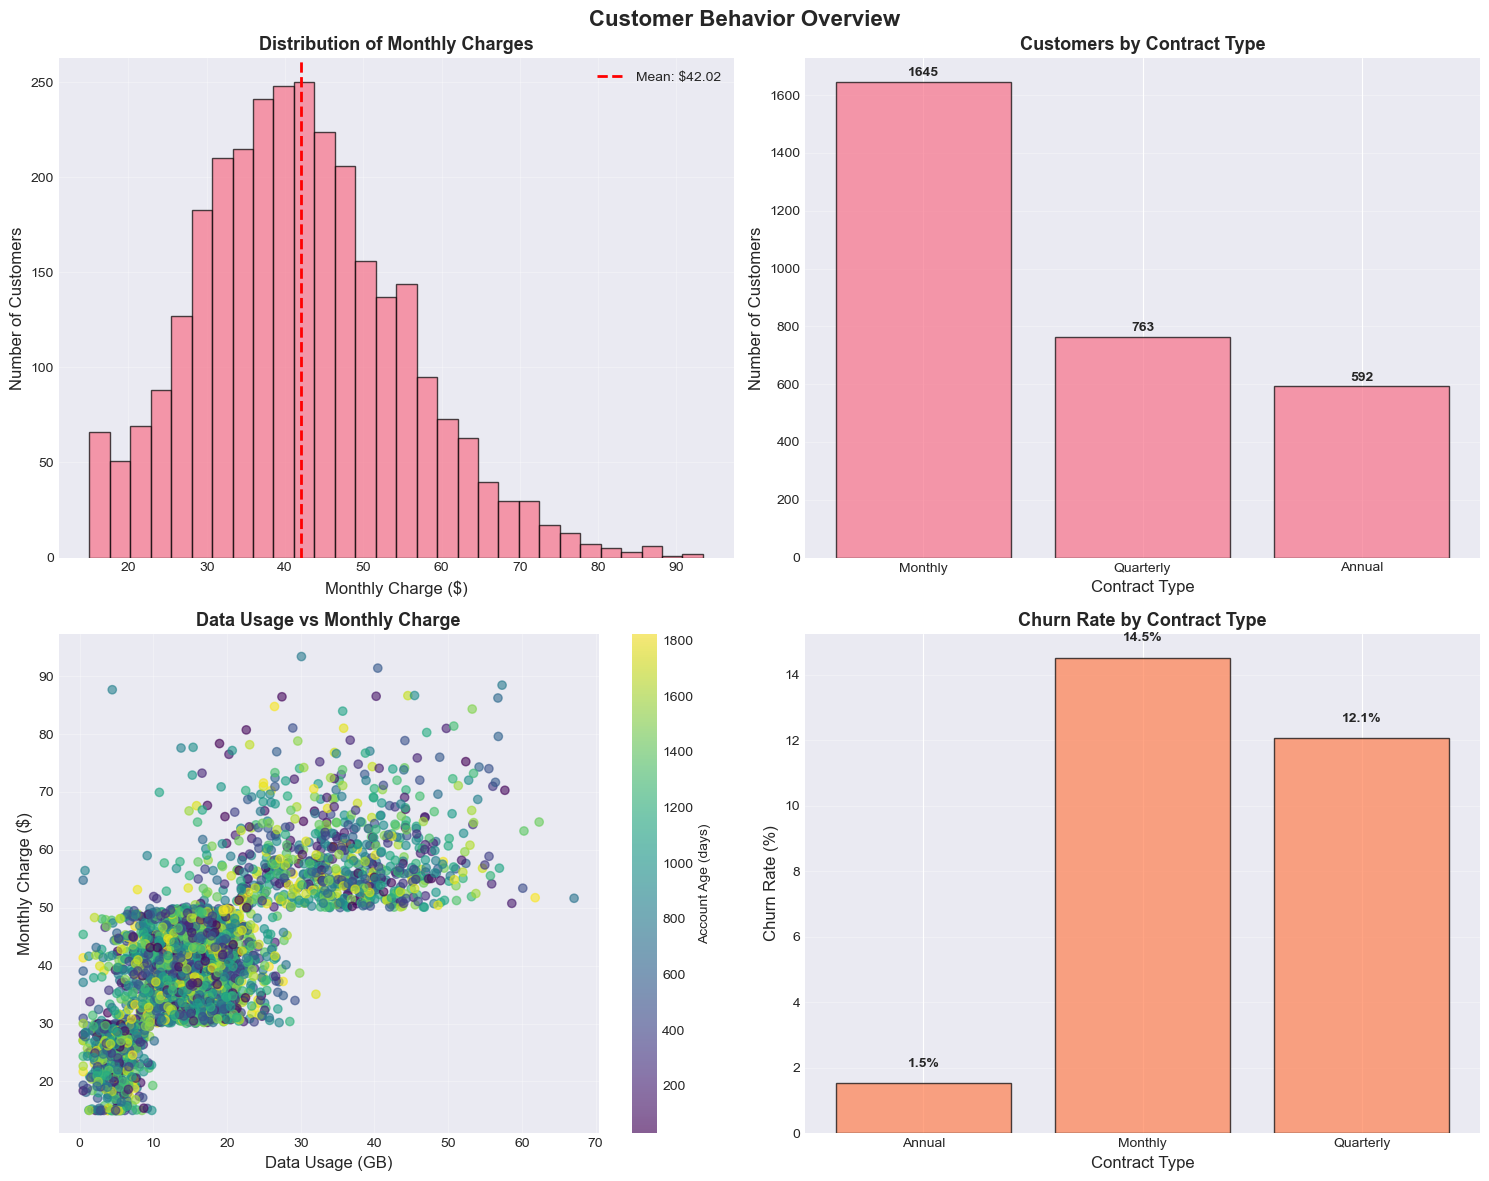


📊 Key Insights:
   • Average monthly charge: $42.02
   • Overall churn rate: 11.3%
   • Most common contract: Monthly


In [6]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Customer Behavior Overview', fontsize=16, fontweight='bold')

# 1. Distribution of monthly charges
axes[0, 0].hist(df['monthly_charge'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['monthly_charge'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["monthly_charge"].mean():.2f}')
axes[0, 0].set_xlabel('Monthly Charge ($)', fontsize=12)
axes[0, 0].set_ylabel('Number of Customers', fontsize=12)
axes[0, 0].set_title('Distribution of Monthly Charges', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Contract type distribution
contract_counts = df['contract_type'].value_counts()
axes[0, 1].bar(contract_counts.index, contract_counts.values, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Contract Type', fontsize=12)
axes[0, 1].set_ylabel('Number of Customers', fontsize=12)
axes[0, 1].set_title('Customers by Contract Type', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, v in enumerate(contract_counts.values):
    axes[0, 1].text(i, v + 20, str(v), ha='center', fontweight='bold')

# 3. Data usage vs Monthly charge (scatter plot)
scatter = axes[1, 0].scatter(df['data_usage_gb'], df['monthly_charge'], 
                            c=df['account_age_days'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('Data Usage (GB)', fontsize=12)
axes[1, 0].set_ylabel('Monthly Charge ($)', fontsize=12)
axes[1, 0].set_title('Data Usage vs Monthly Charge', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Account Age (days)')

# 4. Churn rate by contract type
churn_by_contract = df.groupby('contract_type')['churned'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
axes[1, 1].bar(churn_by_contract.index, churn_by_contract.values, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Contract Type', fontsize=12)
axes[1, 1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1, 1].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, v in enumerate(churn_by_contract.values):
    axes[1, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Key Insights:")
print(f"   • Average monthly charge: ${df['monthly_charge'].mean():.2f}")
print(f"   • Overall churn rate: {(df['churned'] == 'Yes').sum() / len(df) * 100:.1f}%")
print(f"   • Most common contract: {df['contract_type'].mode()[0]}")

---
## Step 4: Feature Engineering

Create new features that might help with segmentation:

In [7]:
# Create new features
df['revenue_per_day'] = df['total_revenue'] / df['account_age_days']
df['usage_intensity'] = df['data_usage_gb'] + (df['call_minutes'] / 100)  # Normalize calls to similar scale
df['support_intensity'] = df['support_calls'] / (df['account_age_days'] / 365)  # Calls per year
df['payment_reliability'] = df['late_payments'] / (df['account_age_days'] / 365)  # Late payments per year

print("✅ New features created:")
print("   • revenue_per_day: Average daily revenue")
print("   • usage_intensity: Combined data + calls metric")
print("   • support_intensity: Support calls per year")
print("   • payment_reliability: Late payments per year")

# Show updated dataframe
df[['customer_id', 'monthly_charge', 'revenue_per_day', 'usage_intensity', 
    'support_intensity', 'payment_reliability']].head()

✅ New features created:
   • revenue_per_day: Average daily revenue
   • usage_intensity: Combined data + calls metric
   • support_intensity: Support calls per year
   • payment_reliability: Late payments per year


,customer_id,monthly_charge,revenue_per_day,usage_intensity,support_intensity,payment_reliability
0,CUST00001,48.59,1.619542,22.61,0.631488,0.315744
1,CUST00002,37.98,1.265970,22.80,0.245131,0.000000
2,CUST00003,61.71,2.056843,43.29,0.820225,0.000000
3,CUST00004,15.82,0.527462,5.88,0.551360,0.275680
4,CUST00005,61.97,2.065612,62.26,1.573276,0.000000


---
## Step 5: Prepare Data for Clustering

Select numerical features and scale them (clustering algorithms need this!):

In [8]:
# Select features for clustering
# We choose features that describe customer behavior and value
features_for_clustering = [
    'monthly_charge',
    'data_usage_gb',
    'call_minutes',
    'account_age_days',
    'late_payments',
    'support_calls',
    'total_revenue',
    'revenue_per_day',
    'usage_intensity',
    'support_intensity'
]

# Create feature matrix
X = df[features_for_clustering].copy()

print(f"Features selected for clustering: {len(features_for_clustering)}")
print(f"Shape of feature matrix: {X.shape}")

# Standardize features (important for K-Means!)
# This makes all features have mean=0 and std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✅ Data scaled and ready for clustering!")
print(f"   Scaled data shape: {X_scaled.shape}")

Features selected for clustering: 10
Shape of feature matrix: (3000, 10)

✅ Data scaled and ready for clustering!
   Scaled data shape: (3000, 10)


---
## Step 6: Find Optimal Number of Clusters

We'll use the **Elbow Method** to determine how many segments we should create:

Testing different numbers of clusters...

k=2: Inertia=20478.26, Silhouette Score=0.363
k=3: Inertia=17622.45, Silhouette Score=0.211
k=4: Inertia=15724.19, Silhouette Score=0.208
k=5: Inertia=14001.18, Silhouette Score=0.220
k=6: Inertia=12789.95, Silhouette Score=0.217
k=7: Inertia=11832.51, Silhouette Score=0.223
k=8: Inertia=11039.93, Silhouette Score=0.216
k=9: Inertia=10514.34, Silhouette Score=0.214
k=10: Inertia=10107.74, Silhouette Score=0.206


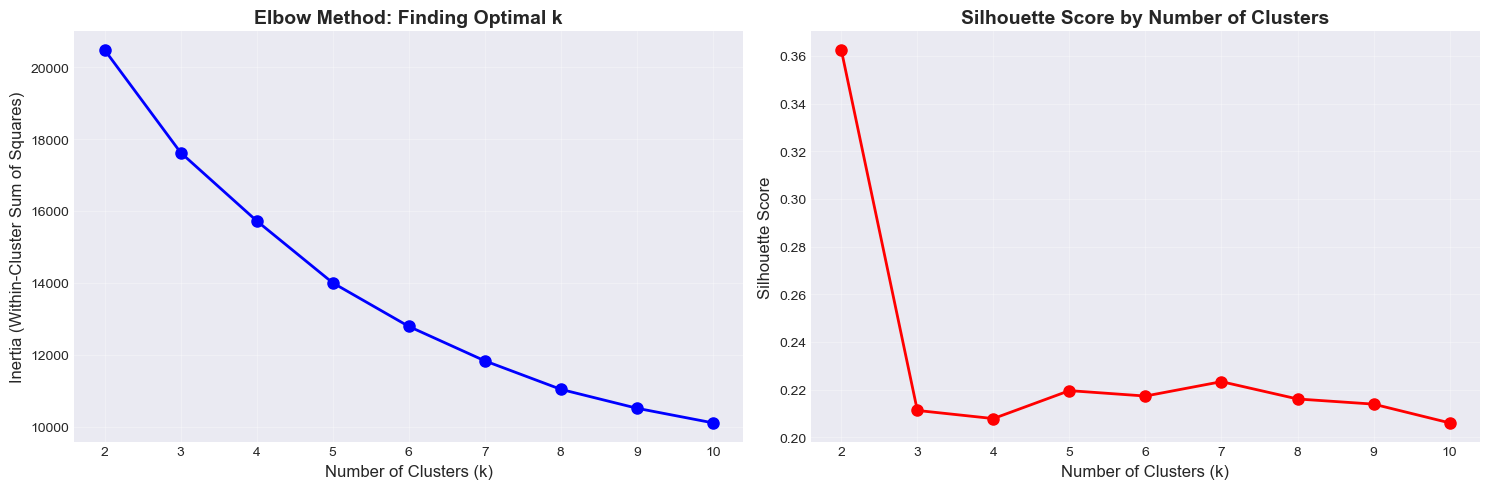


💡 How to interpret:
   • Elbow curve: Look for the 'elbow' where the curve bends
   • Silhouette score: Higher is better (ranges from -1 to 1)
   • We typically choose k=4 or k=5 for good business interpretation


In [9]:
# Test different numbers of clusters (2 to 10)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("Testing different numbers of clusters...\n")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.3f}")

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method: Finding Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by Number of Clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

print("\n💡 How to interpret:")
print("   • Elbow curve: Look for the 'elbow' where the curve bends")
print("   • Silhouette score: Higher is better (ranges from -1 to 1)")
print("   • We typically choose k=4 or k=5 for good business interpretation")

---
## Step 7: Create Customer Segments

Based on the analysis above, let's create 4 customer segments:

✅ Created 4 customer segments!

Segment distribution:
segment
0    1156
1     706
2    1050
3      88
Name: count, dtype: int64


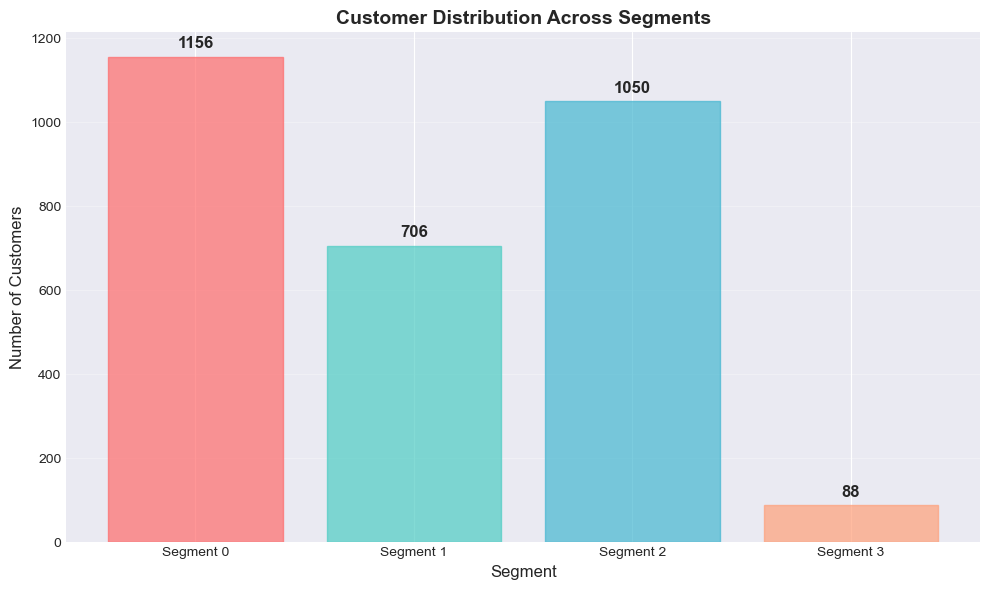

In [10]:
# Create the final model with 4 clusters
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['segment'] = kmeans_final.fit_predict(X_scaled)

print(f"✅ Created {optimal_k} customer segments!")
print(f"\nSegment distribution:")
print(df['segment'].value_counts().sort_index())

# Visualize segment distribution
plt.figure(figsize=(10, 6))
segment_counts = df['segment'].value_counts().sort_index()
bars = plt.bar(segment_counts.index, segment_counts.values, edgecolor='black', alpha=0.7)

# Color each bar differently
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Distribution Across Segments', fontsize=14, fontweight='bold')
plt.xticks(segment_counts.index, [f'Segment {i}' for i in segment_counts.index])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(segment_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

---
## Step 8: Analyze Each Segment

Let's understand what makes each segment unique:

In [11]:
# Calculate segment characteristics
segment_analysis = df.groupby('segment').agg({
    'customer_id': 'count',
    'monthly_charge': 'mean',
    'data_usage_gb': 'mean',
    'call_minutes': 'mean',
    'account_age_days': 'mean',
    'total_revenue': 'mean',
    'late_payments': 'mean',
    'support_calls': 'mean',
    'churned': lambda x: (x == 'Yes').sum() / len(x) * 100
}).round(2)

segment_analysis.columns = ['Count', 'Avg Monthly Charge', 'Avg Data (GB)', 
                            'Avg Call Minutes', 'Avg Account Age (days)', 
                            'Avg Total Revenue', 'Avg Late Payments', 
                            'Avg Support Calls', 'Churn Rate (%)']

print("📊 Segment Characteristics:\n")
print(segment_analysis)

# Most common contract type per segment
print("\n📋 Most Common Contract Type by Segment:")
for segment in sorted(df['segment'].unique()):
    most_common = df[df['segment'] == segment]['contract_type'].mode()[0]
    count = (df[df['segment'] == segment]['contract_type'] == most_common).sum()
    pct = count / len(df[df['segment'] == segment]) * 100
    print(f"   Segment {segment}: {most_common} ({pct:.1f}% of segment)")

📊 Segment Characteristics:

         Count  Avg Monthly Charge  Avg Data (GB)  Avg Call Minutes  \
segment                                                               
0         1156               33.10          10.81            374.17   
1          706               59.50          35.69           1013.72   
2         1050               40.03          14.61            498.25   
3           88               42.57          18.34            537.23   

         Avg Account Age (days)  Avg Total Revenue  Avg Late Payments  \
segment                                                                 
0                        625.03             633.47               0.47   
1                        960.58            1894.71               0.71   
2                       1326.79            1749.07               0.40   
3                         68.60              97.11               0.57   

         Avg Support Calls  Churn Rate (%)  
segment                                     
0               

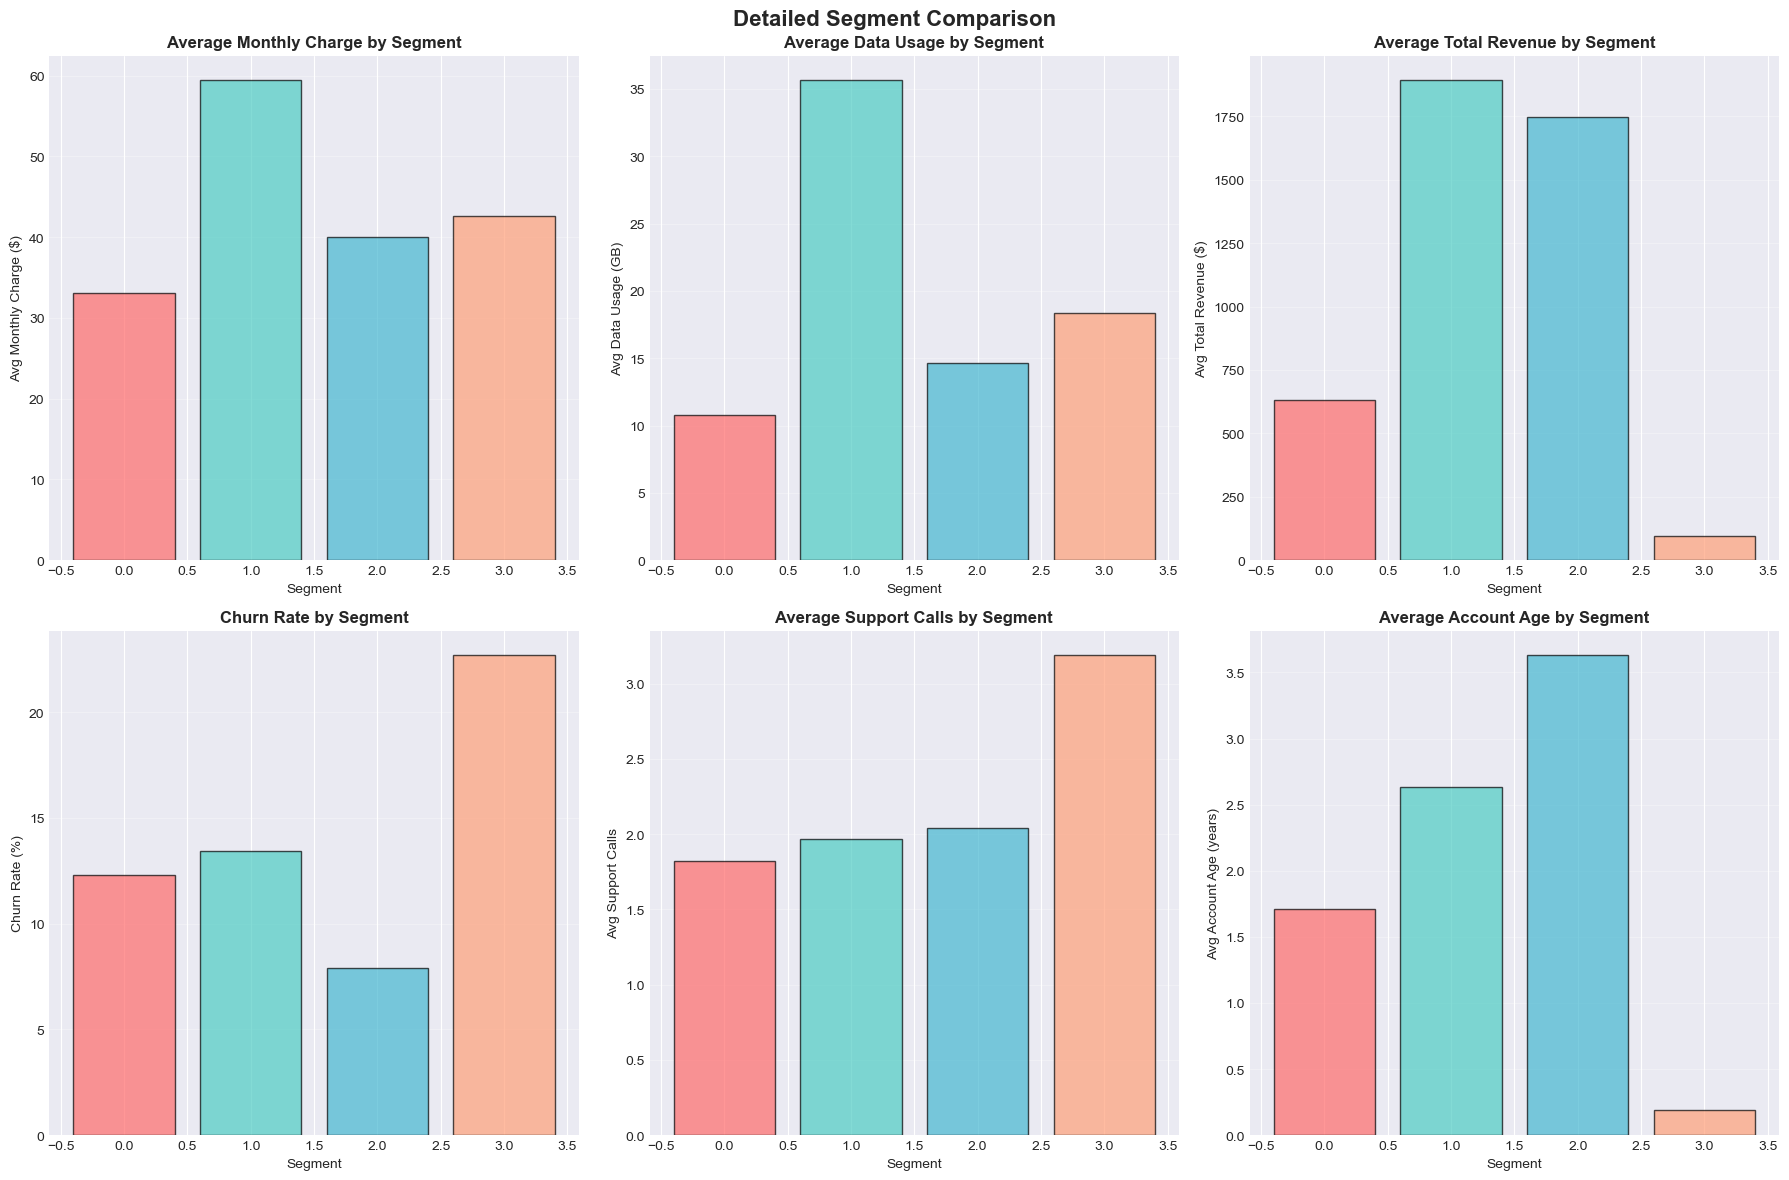

In [12]:
# Visualize segment characteristics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Detailed Segment Comparison', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# 1. Monthly charges by segment
segment_charges = df.groupby('segment')['monthly_charge'].mean()
axes[0, 0].bar(segment_charges.index, segment_charges.values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Segment')
axes[0, 0].set_ylabel('Avg Monthly Charge ($)')
axes[0, 0].set_title('Average Monthly Charge by Segment', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Data usage by segment
segment_data = df.groupby('segment')['data_usage_gb'].mean()
axes[0, 1].bar(segment_data.index, segment_data.values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Avg Data Usage (GB)')
axes[0, 1].set_title('Average Data Usage by Segment', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Total revenue by segment
segment_revenue = df.groupby('segment')['total_revenue'].mean()
axes[0, 2].bar(segment_revenue.index, segment_revenue.values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Segment')
axes[0, 2].set_ylabel('Avg Total Revenue ($)')
axes[0, 2].set_title('Average Total Revenue by Segment', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Churn rate by segment
segment_churn = df.groupby('segment')['churned'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
axes[1, 0].bar(segment_churn.index, segment_churn.values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Segment')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].set_title('Churn Rate by Segment', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Support calls by segment
segment_support = df.groupby('segment')['support_calls'].mean()
axes[1, 1].bar(segment_support.index, segment_support.values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Segment')
axes[1, 1].set_ylabel('Avg Support Calls')
axes[1, 1].set_title('Average Support Calls by Segment', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Account age by segment
segment_age = df.groupby('segment')['account_age_days'].mean() / 365  # Convert to years
axes[1, 2].bar(segment_age.index, segment_age.values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Segment')
axes[1, 2].set_ylabel('Avg Account Age (years)')
axes[1, 2].set_title('Average Account Age by Segment', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Step 9: Name and Interpret Segments

Based on the characteristics, let's give meaningful names to each segment:

In [13]:
# Analyze and name segments based on their characteristics
segment_profiles = {}

for seg in sorted(df['segment'].unique()):
    seg_data = df[df['segment'] == seg]
    
    profile = {
        'Size': len(seg_data),
        'Avg Monthly Charge': seg_data['monthly_charge'].mean(),
        'Avg Data Usage': seg_data['data_usage_gb'].mean(),
        'Avg Revenue': seg_data['total_revenue'].mean(),
        'Churn Rate': (seg_data['churned'] == 'Yes').sum() / len(seg_data) * 100,
        'Avg Account Age (years)': seg_data['account_age_days'].mean() / 365
    }
    
    segment_profiles[seg] = profile

# Create segment names based on analysis
# You can customize these names based on what the data shows
segment_names = {}

# Sort segments by revenue to identify high/low value
sorted_segs = sorted(segment_profiles.items(), key=lambda x: x[1]['Avg Revenue'], reverse=True)

for idx, (seg, profile) in enumerate(sorted_segs):
    if profile['Avg Revenue'] > 2000 and profile['Avg Monthly Charge'] > 50:
        segment_names[seg] = "💎 Premium High-Value"
    elif profile['Churn Rate'] > 15:
        segment_names[seg] = "⚠️ At-Risk"
    elif profile['Avg Monthly Charge'] < 35:
        segment_names[seg] = "💰 Budget-Conscious"
    else:
        segment_names[seg] = "📊 Standard Users"

# Add segment names to dataframe
df['segment_name'] = df['segment'].map(segment_names)

print("\n🎯 CUSTOMER SEGMENT PROFILES:\n")
print("="*80)

for seg in sorted(df['segment'].unique()):
    print(f"\n{segment_names[seg]} (Segment {seg})")
    print("-" * 60)
    
    profile = segment_profiles[seg]
    print(f"   Size: {profile['Size']:,} customers ({profile['Size']/len(df)*100:.1f}% of total)")
    print(f"   Average Monthly Charge: ${profile['Avg Monthly Charge']:.2f}")
    print(f"   Average Data Usage: {profile['Avg Data Usage']:.1f} GB")
    print(f"   Average Total Revenue: ${profile['Avg Revenue']:.2f}")
    print(f"   Churn Rate: {profile['Churn Rate']:.1f}%")
    print(f"   Average Account Age: {profile['Avg Account Age (years)']:.1f} years")
    
    # Most common contract
    seg_data = df[df['segment'] == seg]
    common_contract = seg_data['contract_type'].mode()[0]
    print(f"   Most Common Contract: {common_contract}")

print("\n" + "="*80)


🎯 CUSTOMER SEGMENT PROFILES:


💰 Budget-Conscious (Segment 0)
------------------------------------------------------------
   Size: 1,156 customers (38.5% of total)
   Average Monthly Charge: $33.10
   Average Data Usage: 10.8 GB
   Average Total Revenue: $633.47
   Churn Rate: 12.3%
   Average Account Age: 1.7 years
   Most Common Contract: Monthly

📊 Standard Users (Segment 1)
------------------------------------------------------------
   Size: 706 customers (23.5% of total)
   Average Monthly Charge: $59.50
   Average Data Usage: 35.7 GB
   Average Total Revenue: $1894.71
   Churn Rate: 13.5%
   Average Account Age: 2.6 years
   Most Common Contract: Monthly

📊 Standard Users (Segment 2)
------------------------------------------------------------
   Size: 1,050 customers (35.0% of total)
   Average Monthly Charge: $40.03
   Average Data Usage: 14.6 GB
   Average Total Revenue: $1749.07
   Churn Rate: 7.9%
   Average Account Age: 3.6 years
   Most Common Contract: Monthly

⚠️ At-R

---
## Step 10: Business Recommendations

Based on our segmentation, here are actionable insights:

In [15]:
print("\n📋 BUSINESS RECOMMENDATIONS BY SEGMENT:\n")
print("="*80)

# Get the segments and their details
for seg in sorted(df['segment'].unique()):
    seg_data = df[df['segment'] == seg]
    seg_name = df[df['segment'] == seg]['segment_name'].iloc[0]
    seg_size = len(seg_data)
    seg_revenue = seg_data['total_revenue'].sum()
    
    print(f"\n{seg_name}")
    print(f"   ({seg_size:,} customers, ${seg_revenue:,.2f} total revenue)")
    print("-" * 60)
    
    # Recommendations based on segment characteristics
    if "Premium" in seg_name:
        recs = [
            "Focus on retention with VIP customer service",
            "Offer exclusive perks and loyalty rewards",
            "Proactive account management and check-ins",
            "First access to new features and services"
        ]
    elif "At-Risk" in seg_name:
        recs = [
            "Immediate intervention - personalized retention offers",
            "Investigate root causes of dissatisfaction",
            "Offer contract flexibility or plan adjustments",
            "Enhance customer support quality and response time"
        ]
    elif "Budget" in seg_name:
        recs = [
            "Promote value-for-money bundled packages",
            "Upsell gradually with targeted offers",
            "Highlight cost savings of annual contracts",
            "Focus on basic service reliability"
        ]
    else:  # Standard Users
        recs = [
            "Maintain service quality to prevent churn",
            "Identify upsell opportunities based on usage patterns",
            "Regular engagement through loyalty programs",
            "Monitor for changes that might indicate movement to other segments"
        ]
    
    for i, rec in enumerate(recs, 1):
        print(f"   {i}. {rec}")

print("\n" + "="*80)

# Calculate potential impact from at-risk segment
at_risk_data = df[df['segment_name'].str.contains('At-Risk', na=False)]
if len(at_risk_data) > 0:
    at_risk_revenue = at_risk_data['monthly_charge'].sum()
    print(f"\n💡 IMMEDIATE PRIORITY:")
    print(f"   At-risk segment represents ${at_risk_revenue:,.2f} in monthly recurring revenue")
    print(f"   Even a 10% retention improvement could save ${at_risk_revenue * 0.10:,.2f}/month")
    print(f"   That's ${at_risk_revenue * 0.10 * 12:,.2f} annually!")


📋 BUSINESS RECOMMENDATIONS BY SEGMENT:


💰 Budget-Conscious
   (1,156 customers, $732,293.86 total revenue)
------------------------------------------------------------
   1. Promote value-for-money bundled packages
   2. Upsell gradually with targeted offers
   3. Highlight cost savings of annual contracts
   4. Focus on basic service reliability

📊 Standard Users
   (706 customers, $1,337,665.60 total revenue)
------------------------------------------------------------
   1. Maintain service quality to prevent churn
   2. Identify upsell opportunities based on usage patterns
   3. Regular engagement through loyalty programs
   4. Monitor for changes that might indicate movement to other segments

📊 Standard Users
   (1,050 customers, $1,836,521.27 total revenue)
------------------------------------------------------------
   1. Maintain service quality to prevent churn
   2. Identify upsell opportunities based on usage patterns
   3. Regular engagement through loyalty programs
   4

---
## Step 11: Save Results

Export the segmented customer data for use in marketing campaigns:

In [16]:
# Save the results
output_df = df[['customer_id', 'segment', 'segment_name', 'monthly_charge', 
                'data_usage_gb', 'total_revenue', 'churned', 'contract_type']].copy()

output_df.to_csv('customer_segments.csv', index=False)

print("✅ Results saved to 'customer_segments.csv'")
print(f"\n📊 Summary:")
print(f"   Total customers analyzed: {len(df):,}")
print(f"   Number of segments: {df['segment'].nunique()}")
print(f"   Features used: {len(features_for_clustering)}")
print(f"\nSegment distribution:")
print(df['segment_name'].value_counts())

✅ Results saved to 'customer_segments.csv'

📊 Summary:
   Total customers analyzed: 3,000
   Number of segments: 4
   Features used: 10

Segment distribution:
segment_name
📊 Standard Users      1756
💰 Budget-Conscious    1156
⚠️ At-Risk              88
Name: count, dtype: int64


---
## Conclusion

### What We Accomplished:
1. ✅ Analyzed 3,000 telecom customers
2. ✅ Created 4 distinct customer segments using K-Means clustering
3. ✅ Identified high-value, at-risk, budget-conscious, and standard customer groups
4. ✅ Provided actionable business recommendations for each segment

### Business Impact:
- **Targeted Marketing**: Can now create specific campaigns for each segment
- **Churn Reduction**: Identified at-risk customers for proactive retention
- **Revenue Growth**: Found upsell opportunities in standard and budget segments
- **Resource Optimization**: Can allocate support and marketing resources more effectively

### Next Steps:
1. Implement segment-specific marketing campaigns
2. Monitor segment migration over time
3. A/B test retention strategies on at-risk segment
4. Refine segmentation with additional data (e.g., customer satisfaction scores)

---
*This analysis was created as part of a data analytics portfolio project.*